In [2]:
using Geant4
using Geant4.SystemOfUnits
using GLMakie, Rotations, LinearAlgebra, IGLWrap_jll  # to force loading G4Vis extension
using FHist, Plots

# Making the struct for parameters

In [3]:
mutable struct B4aDetector <: G4JLDetector
    # main input parameters  
    const nofLayers::Int
    const checkOverlaps::Bool 
    const absoThickness::Float64
    const gapThickness::Float64
    const calorSizeXY::Float64
   
    # constructor with defaults values for parameters
    function B4aDetector(;      nofLayers::Int=10,
                                checkOverlaps::Bool=true,
                                absoThickness::Float64=10mm,
                                gapThickness::Float64=5mm,
                                calorSizeXY::Float64=10cm)
            self = new(nofLayers, checkOverlaps, absoThickness, gapThickness, calorSizeXY)
            # Setup some geometry
            #self.worldZHalfLength = 1.2 * (2*targetLength +  (nChambers+1) * chamberSpacing) /2 
        return self
    end
end
_layerThickness(d::B4aDetector) = d.absoThickness + d.gapThickness
_calorThickness(d::B4aDetector) = d.nofLayers * _layerThickness(d)
_worldSizeZ(d::B4aDetector) = 1.2 * _calorThickness(d)
_worldSizeXY(d::B4aDetector) = 1.2 * d.calorSizeXY

_worldSizeXY (generic function with 1 method)

# Defining the  geometry

In [4]:
function B4aConstruct(det::B4aDetector)::CxxPtr{G4VPhysicalVolume}
    (; nofLayers, checkOverlaps, absoThickness, gapThickness, calorSizeXY) = det
    nist = G4NistManager!Instance() 

    
    layerThickness = _layerThickness(det)
    calorThickness = _calorThickness(det)
    worldSizeXY = _worldSizeXY(det)
    worldSizeZ = _worldSizeZ(det)

    G4Material("liquidArgon", z = 18., a = 30.95g/mole, density = 1.390g/cm3)

    defaultMaterial = FindOrBuildMaterial(nist, "G4_Galactic")
    absorberMaterial = FindOrBuildMaterial(nist, "G4_Pb")
    gapMaterial = FindOrBuildMaterial(nist, "liquidArgon")



    worldS = G4Box("World", 0.5 * worldSizeXY, 0.5 * worldSizeXY, 0.5 * worldSizeZ)
    
    worldLV = G4LogicalVolume(worldS, defaultMaterial, "WorldLV")
  
    worldPV = G4PVPlacement(nothing,          # no rotation
                            G4ThreeVector(),  # at (0,0,0)
                            worldLV,          # its logical volume
                            "World",          # its name
                            nothing,          # its mother volume
                            false,            # no boolean operation
                            0,                # copy number
                            checkOverlaps)    # overlaps checking

#---------------------------------------
    calorimeterS = G4Box("Calorimeter", 0.5 * calorSizeXY, 0.5 * calorSizeXY, 0.5 * calorThickness)
    

    calorLV = G4LogicalVolume(calorimeterS, defaultMaterial, "CalorLV")

    println(calorLV)

    G4PVPlacement(nothing,                                                    
                    G4ThreeVector(),
                    calorLV,  
                    "CalorPV",                                                                         
                    worldLV,           
                    false,            
                    0,                         
                    checkOverlaps)
#----------------------------------------------

     layerS = G4Box("Layer",                                                                          
                    0.5*calorSizeXY, 0.5*calorSizeXY, 0.5*layerThickness)                            

     layerLV = G4LogicalVolume(layerS,
                           defaultMaterial, 
                           "Layer")
    
    G4PVReplica("Layer",
                  layerLV,
                  calorLV,
                  kZAxis,
                  nofLayers,
                  layerThickness)
		  
#---------------------------------------------------
   absorberS = G4Box("Abso",                                                                        
                      0.5*calorSizeXY, 0.5*calorSizeXY, 0.5*absoThickness)                          

    absorberLV = G4LogicalVolume(absorberS, absorberMaterial, "AbsoLV")

    G4PVPlacement(nothing,                                              
                  G4ThreeVector(0., 0., -0.5*gapThickness),
                    absorberLV,
                    "AbsPV",
                    layerLV,
                    false, 
                    0,
                    checkOverlaps)
#--------------------------------------

  gapS = G4Box("Gap", 0.5*calorSizeXY, 0.5*calorSizeXY, 0.5*gapThickness)

  gapLV = G4LogicalVolume(gapS, gapMaterial, "Gap")

  G4PVPlacement(nothing,
                G4ThreeVector(0., 0., 0.5*absoThickness),
                gapLV,
                "GapPV",
                layerLV,
                false,
                0,
                checkOverlaps)


#------------------------------------------
#Visualization attributes              
    SetVisAttributes(worldLV, G4VisAttributes!GetInvisible())
    SetVisAttributes(calorLV, G4VisAttributes!GetInvisible())   
                  
return worldPV              # return a pointer to the G4PhysicalVolume
#add the magnetic field remaining
end

B4aConstruct (generic function with 1 method)

In [5]:
detector = B4aDetector()

B4aDetector(10, true, 10.0, 5.0, 100.0)

# Primary generator

In [6]:
worldZHalfLength = _worldSizeZ(detector)/2
particlegun = G4JLGunGenerator(particle = "e-",
                               energy = 300MeV,
                               direction = G4ThreeVector(0., 0., 1.),
                               position = G4ThreeVector(0,0,-worldZHalfLength))

G4JLGunGenerator("ParticleGun", Geant4.G4JLParticleGunData(nothing, "e-", G4ThreeVector(0.0,0.0,1.0), G4ThreeVector(0.0,0.0,-90.0), 300.0), Geant4.var"#init#19"(), Geant4.var"#gen#20"(), G4JLGeneratorAction[])

# Defining the simulation data

In [7]:
const Hist1D64 = Hist1D{Float64}
mutable struct B4aSimData <: G4JLSimulationData    
    fEnergyDeposit_Abs::Float64
    fEnergyDeposit_Gap::Float64
    
    fStepLength_Abs::Float64
    fStepLength_Gap::Float64   
    
    fEdepHist_Abs::Hist1D64
    fStepLenHist_Abs::Hist1D64
    
    fEdepHist_Gap::Hist1D64
    fStepLenHist_Gap::Hist1D64
    
    B4aSimData() = new()
end

# Run Action

In [68]:
# ##---End Run Action---------------------------------------------------------------------------------
function beginrun(run::G4Run, app::G4JLApplication)::Nothing
    data = getSIMdata(app)
    
    data.fEdepHist_Abs = Hist1D(;binedges=100.:1.:300.)
    data.fStepLenHist_Abs = Hist1D(;binedges=0.:2.:500.)
    
    data.fEdepHist_Gap = Hist1D(;binedges=0.:1.:200.)
    data.fStepLenHist_Gap = Hist1D(;binedges=0.:2.:500.)
    nothing
end

##---End Run Action---------------------------------------------------------------------------------
function endrun(run::G4Run, app::G4JLApplication)::Nothing
    nothing
end


endrun (generic function with 1 method)

# Event Action

In [69]:
function beginevent(evt::G4Event, app::G4JLApplication)
    G4JL_println("===============started event $(evt |> GetEventID)")
    data = getSIMdata(app)
    data.fEnergyDeposit_Abs = 0.0
    data.fStepLength_Abs = 0.0
    
    data.fEnergyDeposit_Gap = 0.0
    data.fStepLength_Gap = 0.0
    return
end

beginevent (generic function with 1 method)

In [70]:
function endevent(evt::G4Event, app::G4JLApplication)
    data = getSIMdata(app)    
#     G4JL_println("AbsEdep: $(data.fEnergyDeposit_Abs)")
#     println("AbsStepLength: ", data.fStepLength_Abs)
    
    push!(data.fEdepHist_Abs, data.fEnergyDeposit_Abs)
    push!(data.fStepLenHist_Abs, data.fStepLength_Abs)
    
    push!(data.fEdepHist_Gap, data.fEnergyDeposit_Gap)
    push!(data.fStepLenHist_Gap, data.fStepLength_Gap)

    println("Total Energy deposited in Absorber: ",data.fEnergyDeposit_Abs)
    println("Total Energy deposited in Gaps: ", data.fEnergyDeposit_Gap)
    G4JL_println("================event ended $(evt |> GetEventID) \n")
    return
end

endevent (generic function with 1 method)

# Stepping Action

In [71]:
function stepaction(step::G4Step, app::G4JLApplication)
    data = getSIMdata(app)
    
    volume = step |> GetPreStepPoint |> GetPhysicalVolume |> GetName
    edep = step |> GetTotalEnergyDeposit
    
    stepLength = 0
    if step |> GetTrack |> GetDefinition |> GetPDGCharge != 0.
        stepLength = step |> GetStepLength        
    end
    
    if volume[] == "AbsPV"  
        data.fEnergyDeposit_Abs += edep
        data.fStepLength_Abs += stepLength
    end
        
    if volume[] == "GapPV"  
        data.fEnergyDeposit_Gap += edep
        data.fStepLength_Gap += stepLength
    end
    return
end

stepaction (generic function with 1 method)

# Making the Application

In [72]:
#---Event Display----------------------------------------------------------------------------------
evtdisplay   = G4JLEventDisplay(joinpath(@__DIR__, "B4aVis.jl"))


G4Vis.G4JLEventDisplay((display = (backgroundcolor = :black, resolution = (1280, 720), show_axis = true, camera_rotation = (0, 0, 0), camera_zoom = 0.1), trajectories = (color = :yellow,), detector = (show_detector = true,)), G4Vis.stateChange, G4Vis.initDisplay, #undef, #undef)

In [73]:
Geant4.getConstructor(::B4aDetector)::Function = B4aConstruct

In [74]:
app = G4JLApplication(detector = detector,          ## detector with parameters
                      simdata = B4aSimData(),     ##simulation data
                      generator = particlegun,                      ## primary particle generator
                      nthreads = 0,                                 ## # of threads (0 = no MT)
                      physics_type = FTFP_BERT,                 ## what physics list to instantiate
                      evtdisplay   = evtdisplay,                 # event display
                      stepaction_method = stepaction,
                      beginrunaction_method = beginrun,           ## begin-run action (initialize counters and histograms)
                      endrunaction_method = endrun,    
                      begineventaction_method=beginevent,
                      endeventaction_method = endevent
                     )

configure(app)
initialize(app)

In [76]:
# img = do_plot(app.simdata[1])
# display("image/png", img)

In [79]:
# ui`/tracking/verbose 1`
beamOn(app,100)
#display(evtdisplay.figure)

===============started event 0
Total Energy deposited in Absorber: 273.6264878350379
Total Energy deposited in Gaps: 13.062608562584298
================event ended 0 

===============started event 1
Total Energy deposited in Absorber: 267.5007041712927
Total Energy deposited in Gaps: 17.085596921507697
================event ended 1 

===============started event 2
Total Energy deposited in Absorber: 277.24030183403937
Total Energy deposited in Gaps: 10.830903383861669
================event ended 2 

===============started event 3
Total Energy deposited in Absorber: 278.1953166021273
Total Energy deposited in Gaps: 11.259415104218073
================event ended 3 

===============started event 4
Total Energy deposited in Absorber: 273.93799016091396
Total Energy deposited in Gaps: 14.568417685335792
================event ended 4 

===============started event 5
Total Energy deposited in Absorber: 284.93492802618266
Total Energy deposited in Gaps: 5.310827876831256
================event 

Total Energy deposited in Absorber: 245.74656423555143
Total Energy deposited in Gaps: 7.735333686991054
================event ended 50 

===============started event 51
Total Energy deposited in Absorber: 263.22432156402994
Total Energy deposited in Gaps: 13.028524214965529
================event ended 51 

===============started event 52
Total Energy deposited in Absorber: 287.8470925676095
Total Energy deposited in Gaps: 8.101963603487397
================event ended 52 

===============started event 53
Total Energy deposited in Absorber: 270.1344451231903
Total Energy deposited in Gaps: 14.256998301759376
================event ended 53 

===============started event 54
Total Energy deposited in Absorber: 269.6966411186107
Total Energy deposited in Gaps: 23.94398850450702
================event ended 54 

===============started event 55
Total Energy deposited in Absorber: 281.57104372705544
Total Energy deposited in Gaps: 16.440107192742918
================event ended 55 

============

# Plotting the histograms

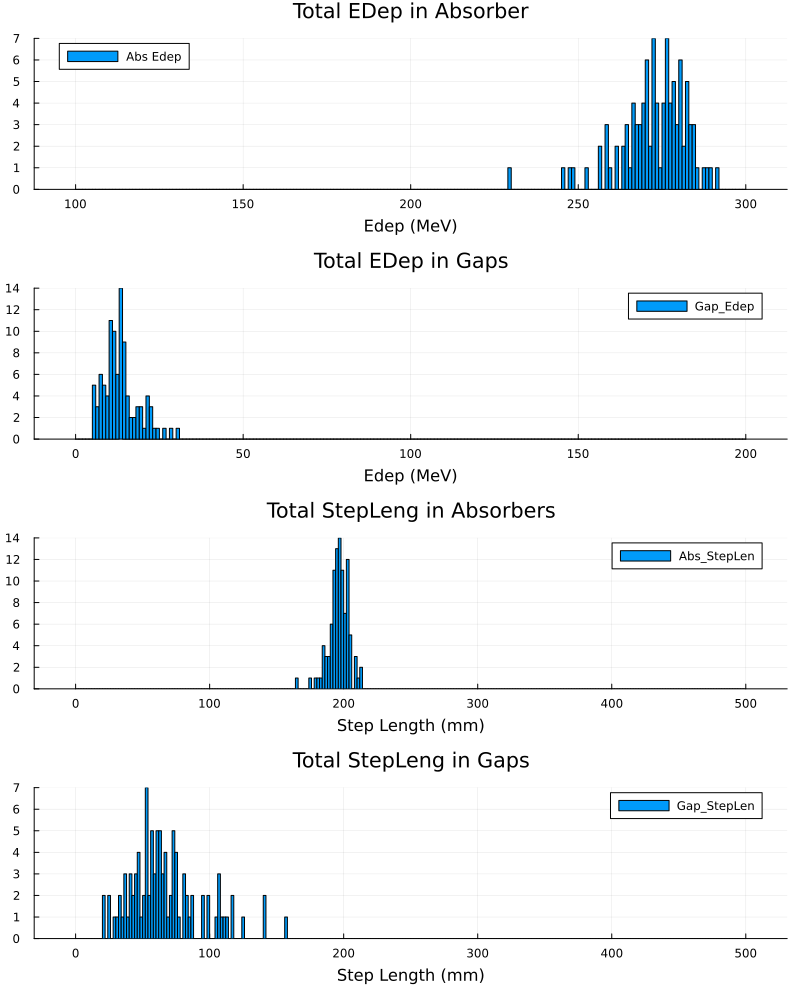

In [80]:
# function do_plot(data::B4aSimData)
    #(;fEdepHist_Abs, fStepLenHist_Abs, fEdepHist_Gap, fStepLenHist_Gap) = data
        data = getSIMdata(app)
        lay = @layout [°; °; °; °]
        img = Plots.plot(layout=lay, show=true, size=(800,1000))

        Plots.plot!(subplot=1, data.fEdepHist_Abs, title="Total EDep in Absorber", xlabel="Edep (MeV)", label="Abs Edep", show=true)
        Plots.plot!(subplot=2, data.fEdepHist_Gap, title="Total EDep in Gaps", xlabel="Edep (MeV)", label="Gap_Edep", show=true)

        Plots.plot!(subplot=3, data.fStepLenHist_Abs, title="Total StepLeng in Absorbers", xlabel="Step Length (mm)", label="Abs_StepLen", show=true)
        Plots.plot!(subplot=4, data.fStepLenHist_Gap, title="Total StepLeng in Gaps", xlabel="Step Length (mm)", label="Gap_StepLen", show=true)
        display("image/png", img)